In [60]:
import numpy as np
import subprocess
import os
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")
import importlib

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import itertools
import grafici as gf
importlib.reload(gf)

from scipy.stats import chi2
import funzioni as f

In [61]:
bin = 1
# Inclusione grafici Mengoni
M = False
# Zoom del grafico
index_inizio = 320
index_fine = 405

# 1. Raccolta Dati

### 1.1 Lettura Cartella Raw

In [62]:
if M == True:
    input_files = [f"./Raw/{f}" for f in os.listdir('./Raw')]
else:
    input_files = [f"./Raw/{f}" for f in os.listdir('./Raw') if 'M' not in f]

### 1.2 Creazione Liste

In [63]:
output_files,titoli=[],[]
for input in input_files:
    output_files.append(input.replace('.csv', '.txt').replace('Raw','Data'))
    titoli.append(input.replace('.csv','').replace("./Raw/Ispector_65_Spectrum_",""))

### 1.3 Conversione RawToData

In [64]:
for input, output in zip(input_files,output_files):
     try:
          subprocess.run(['./RawToData.exe', '-in', input, '-out', output, '-rebin', str(bin)], stdout=subprocess.DEVNULL, check=True)
          print(f"{input:<40} convertito con successo")
     except subprocess.CalledProcessError as e:
          print(f"Errore durante l'esecuzione: {e}")

./Raw/Ispector_65_Spectrum_1h.csv        convertito con successo
./Raw/Ispector_65_Spectrum_40min.csv     convertito con successo
./Raw/Ispector_65_Spectrum_1h20m.csv     convertito con successo
./Raw/Ispector_65_Spectrum_11min.csv     convertito con successo
./Raw/Ispector_65_Spectrum_2min.csv      convertito con successo
./Raw/Ispector_65_Spectrum_20min.csv     convertito con successo


# 2. Grafici e Fit

### 2.1 Funzioni

In [70]:
def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

def lin_func(x, a, b):
    return a + b * x

### 2.2 Indici

In [ ]:
i1 = index_inizio
i2 = index_inizio + 15 + 1
i3 = index_fine - 15
i4 = index_fine + 1
print(f"{i1}\n{i2}\n{i3}\n{i4}")

320
335
390
405


### 2.2 Calcolo Fit

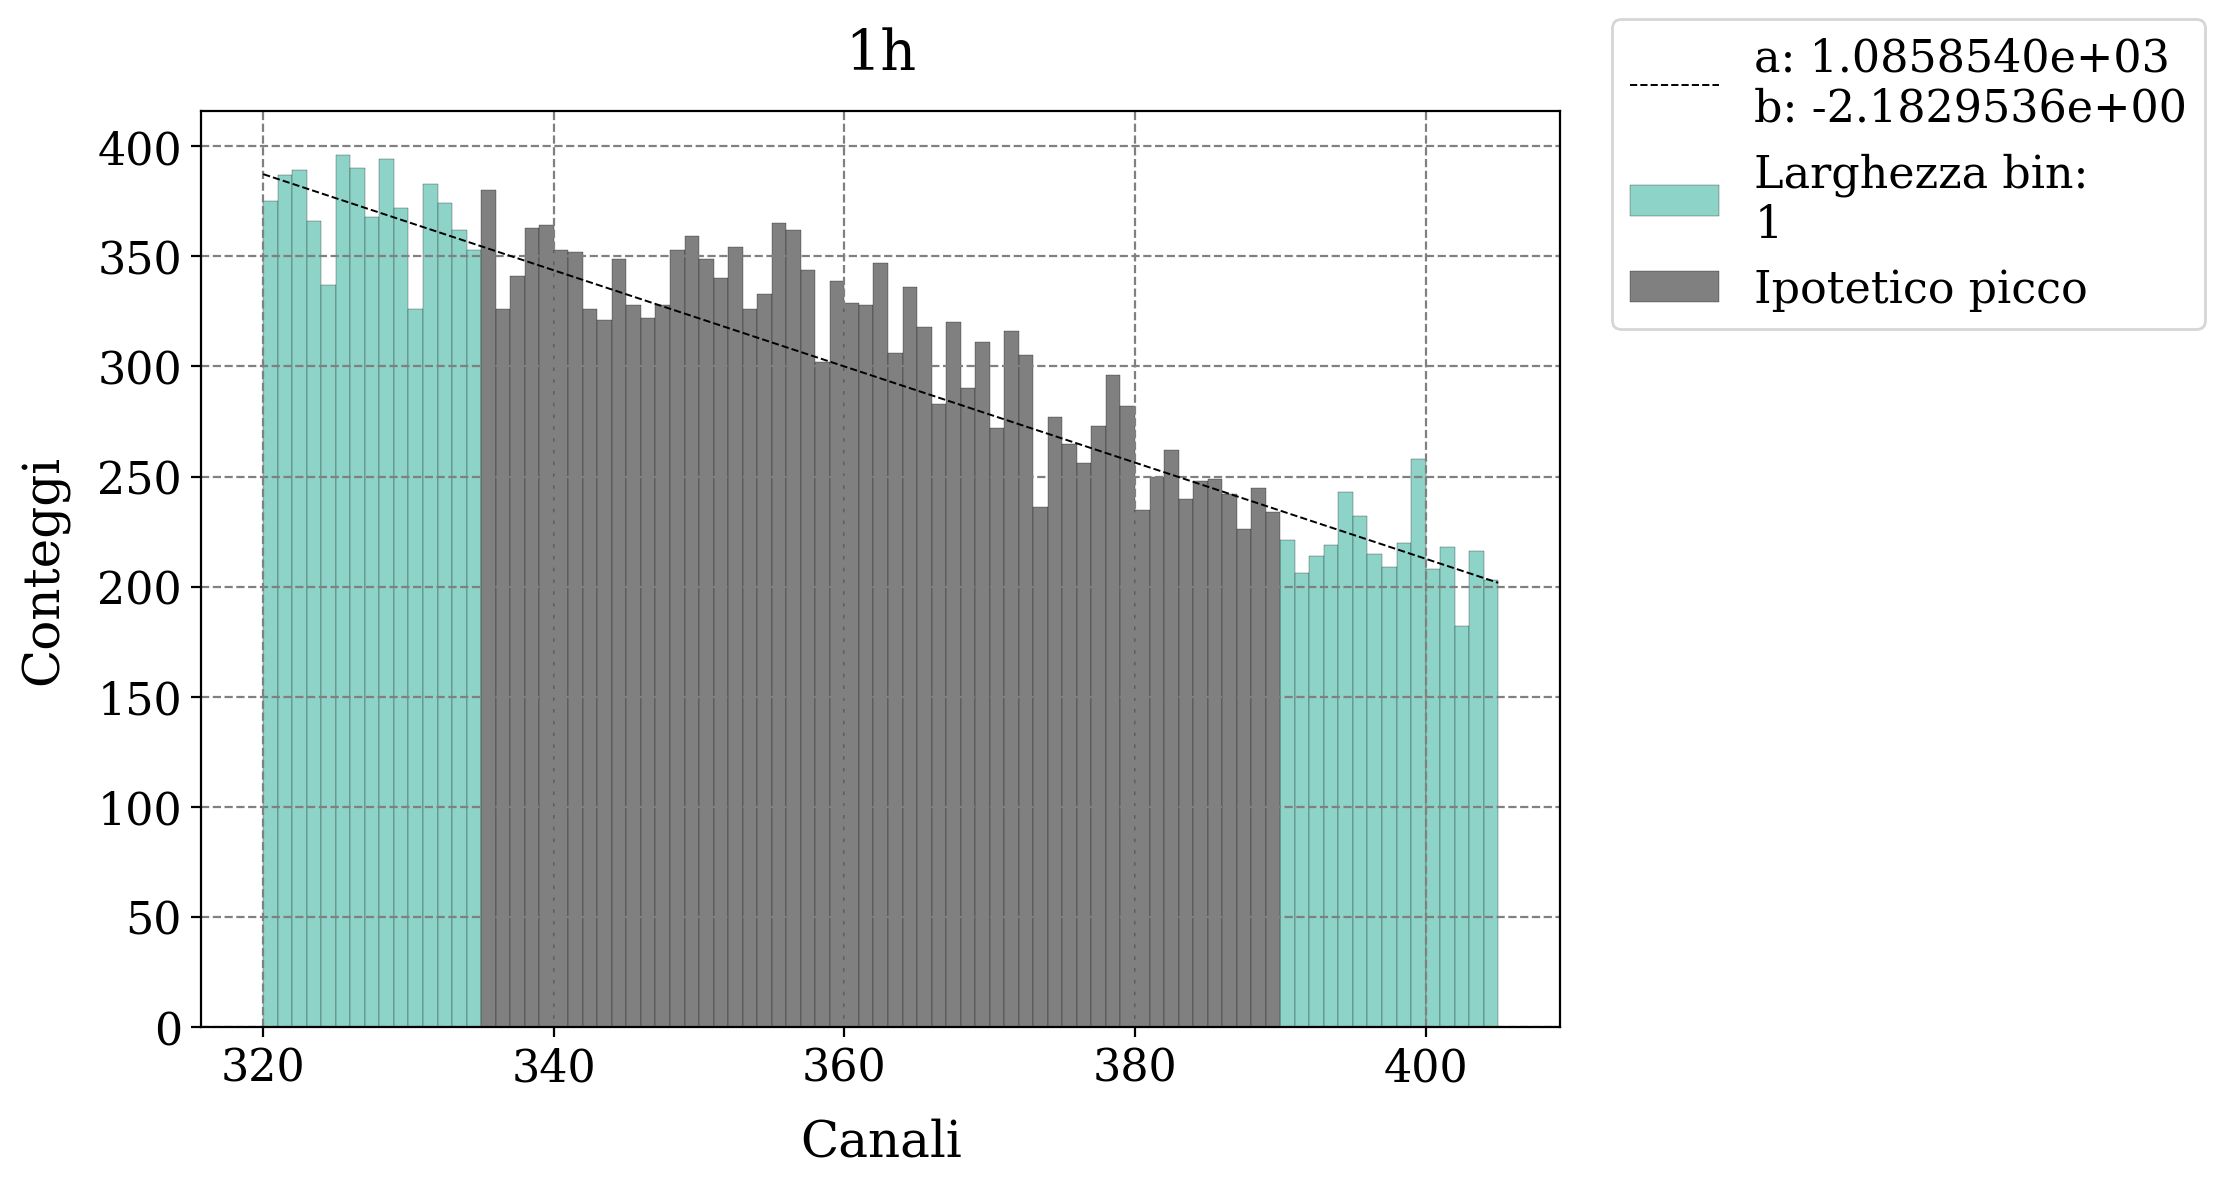

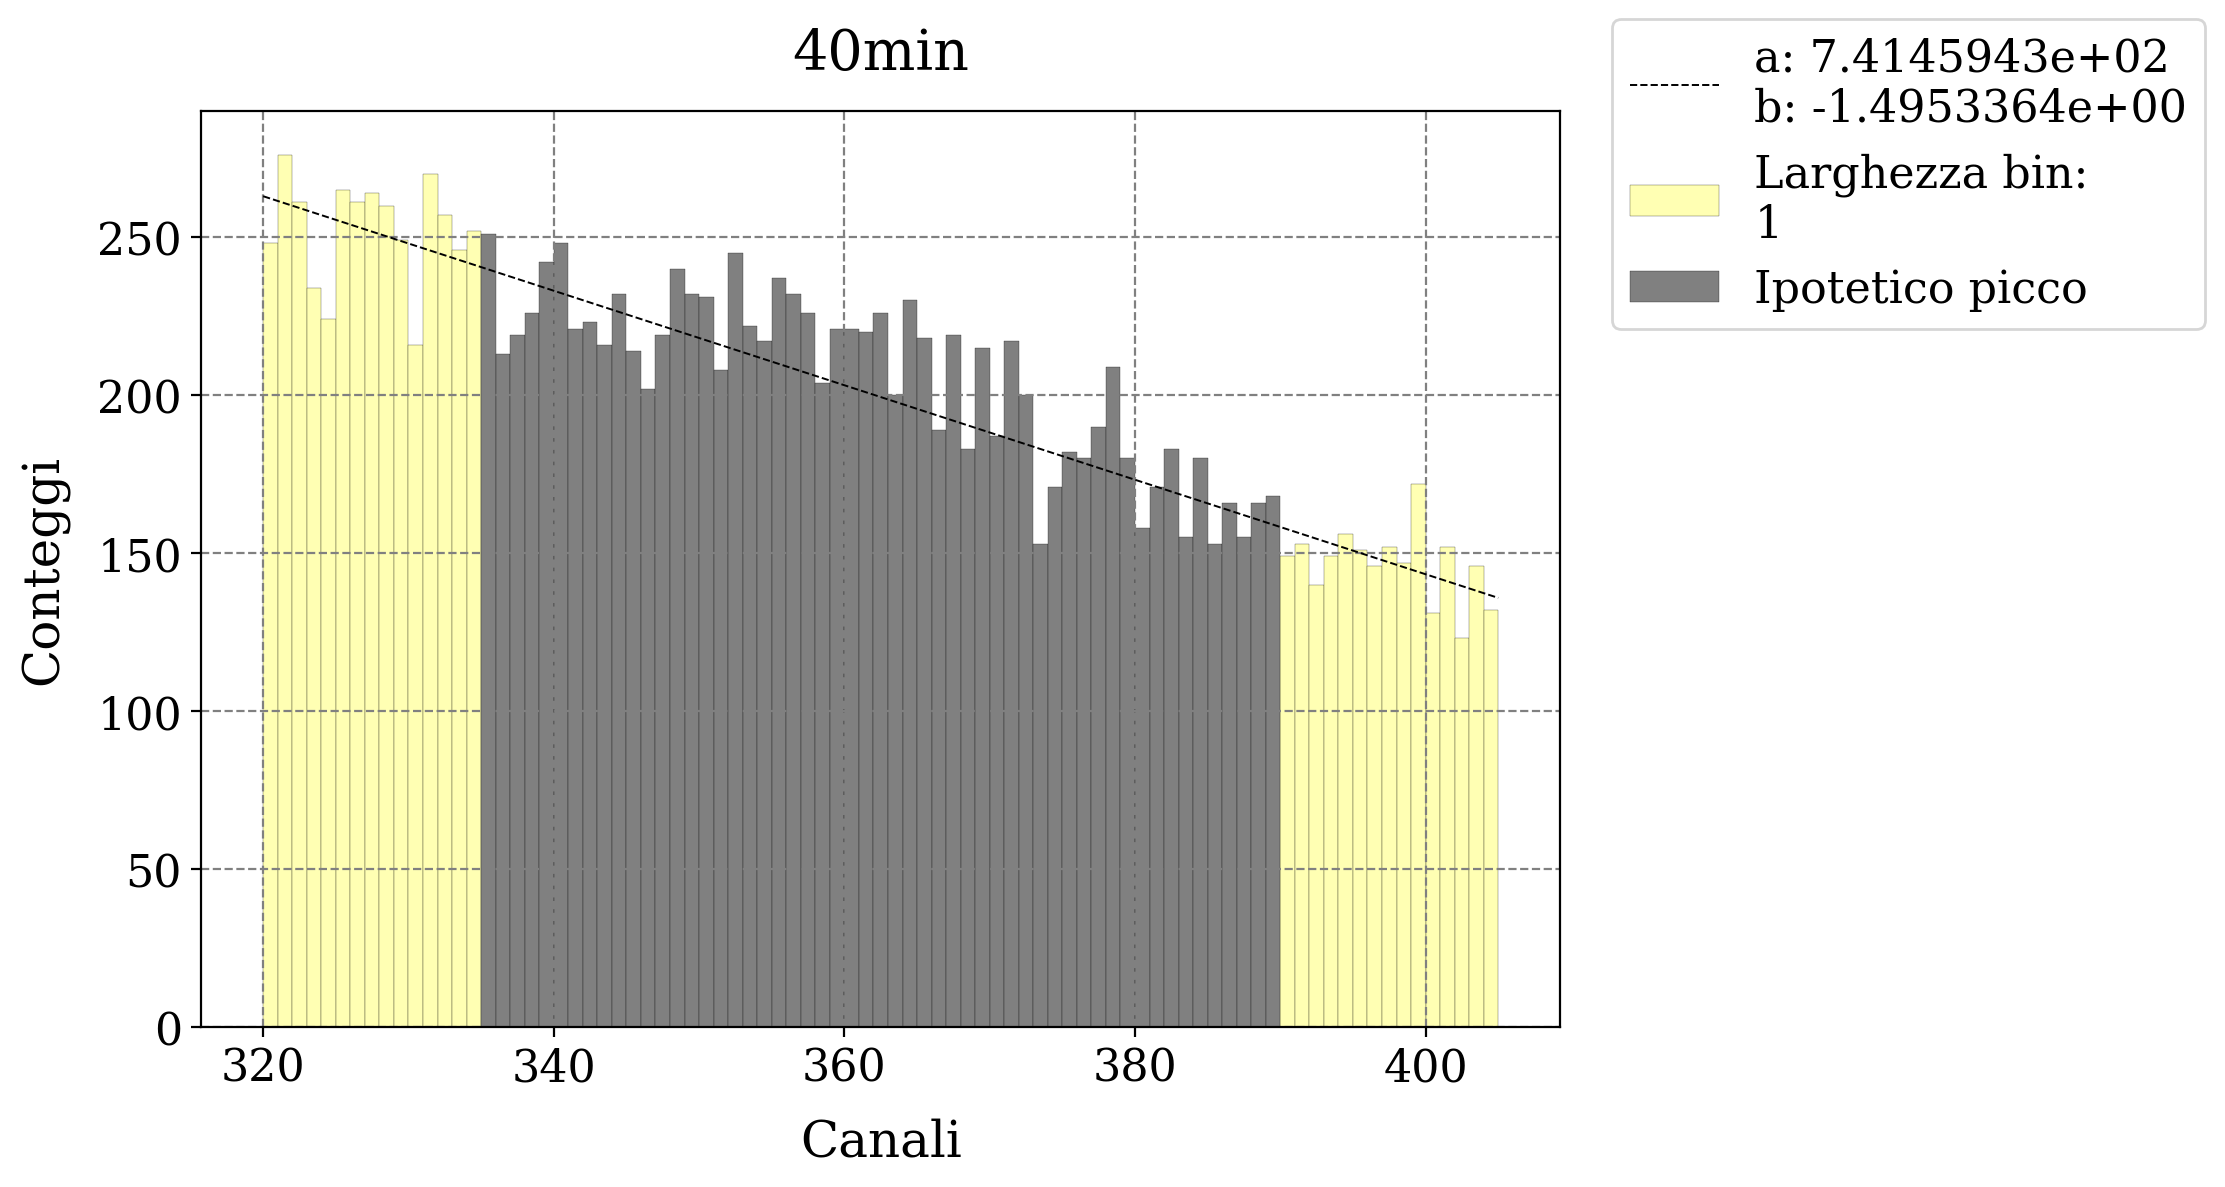

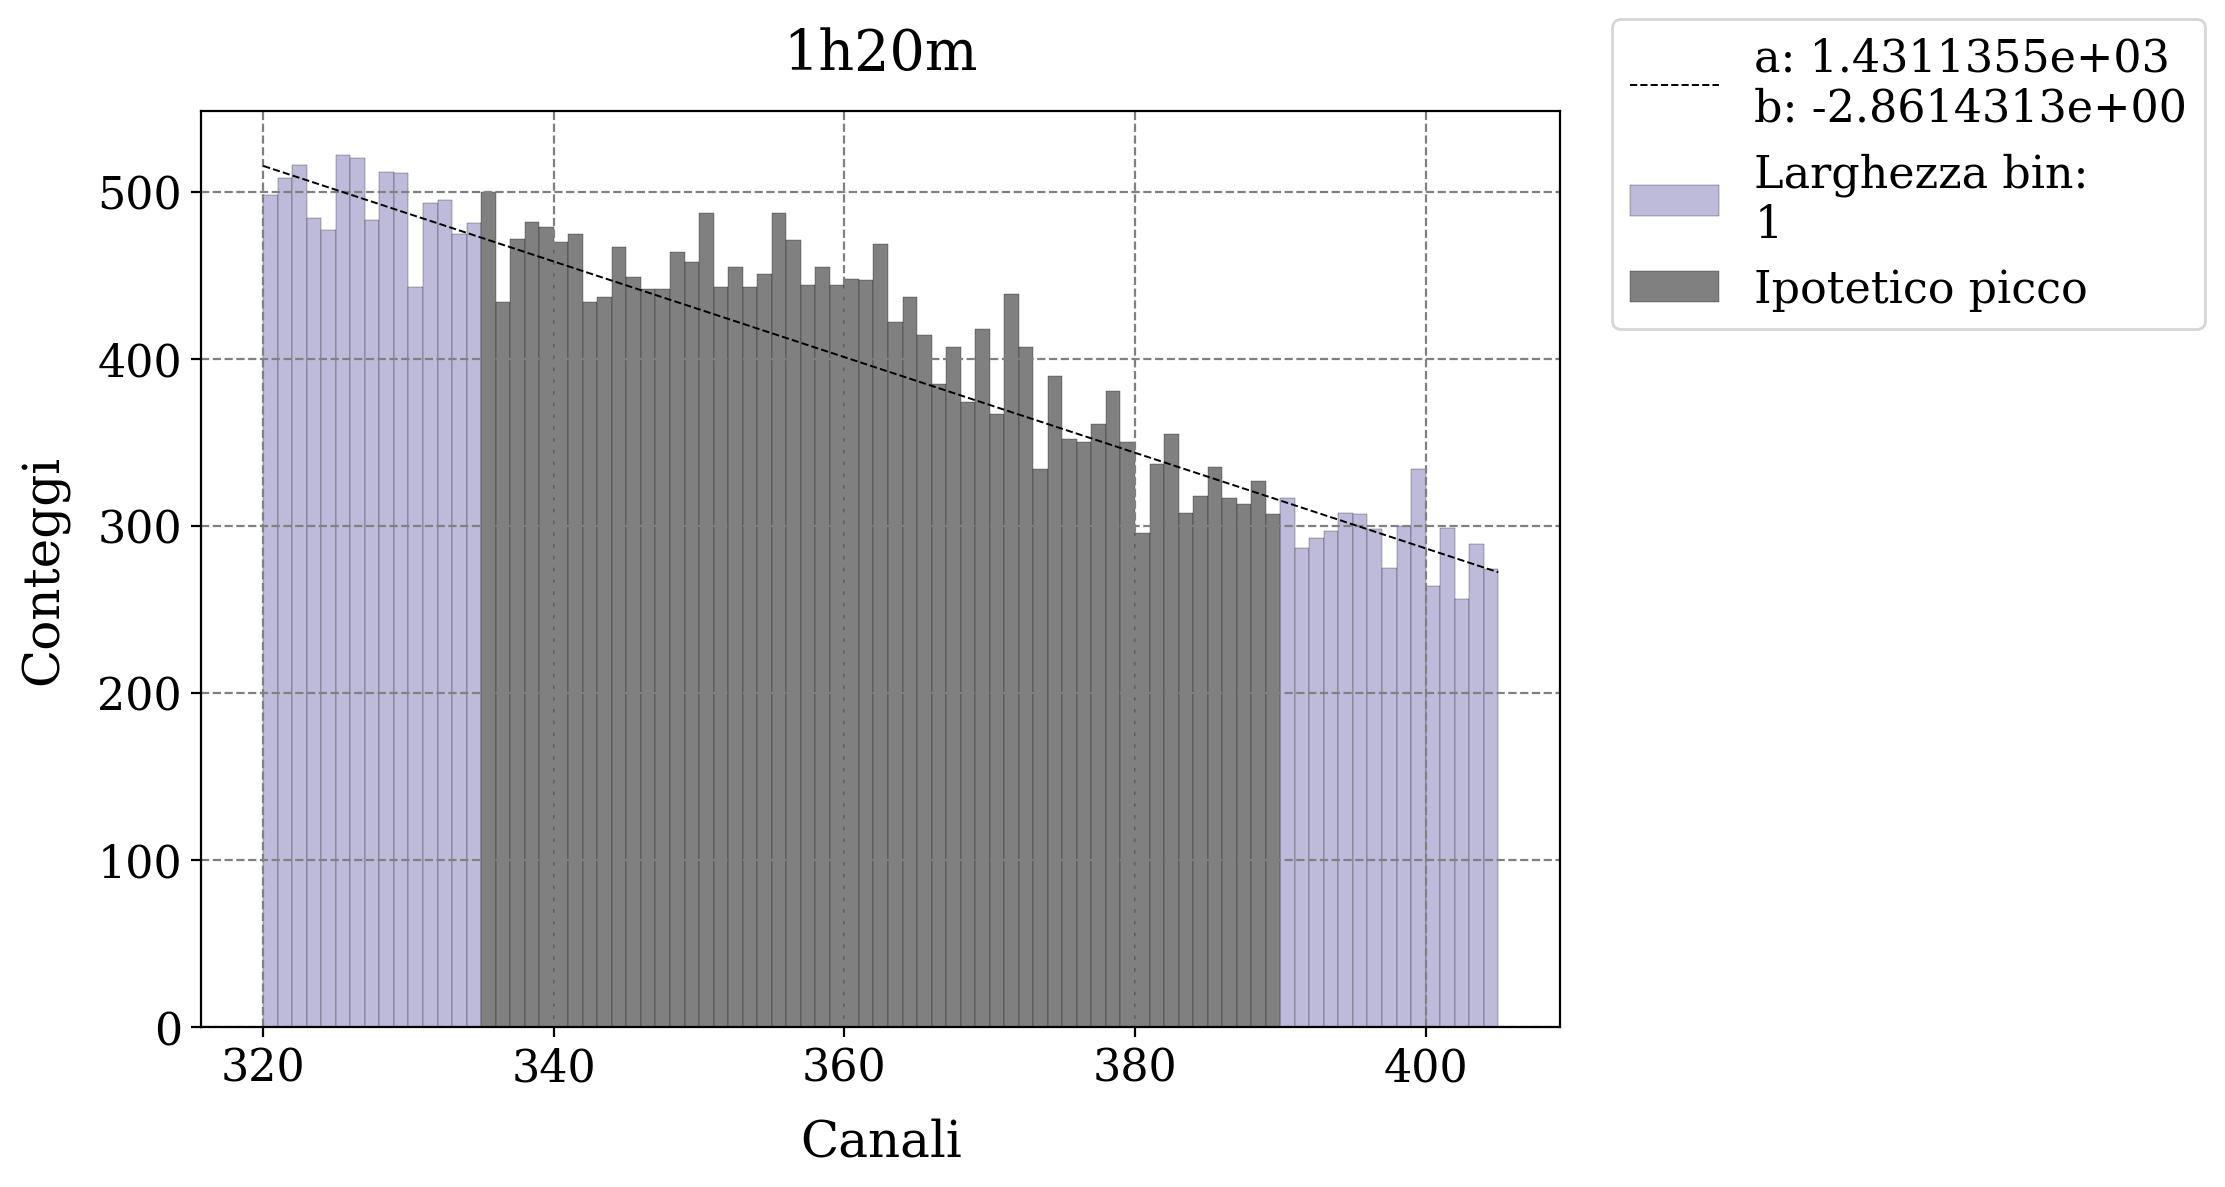

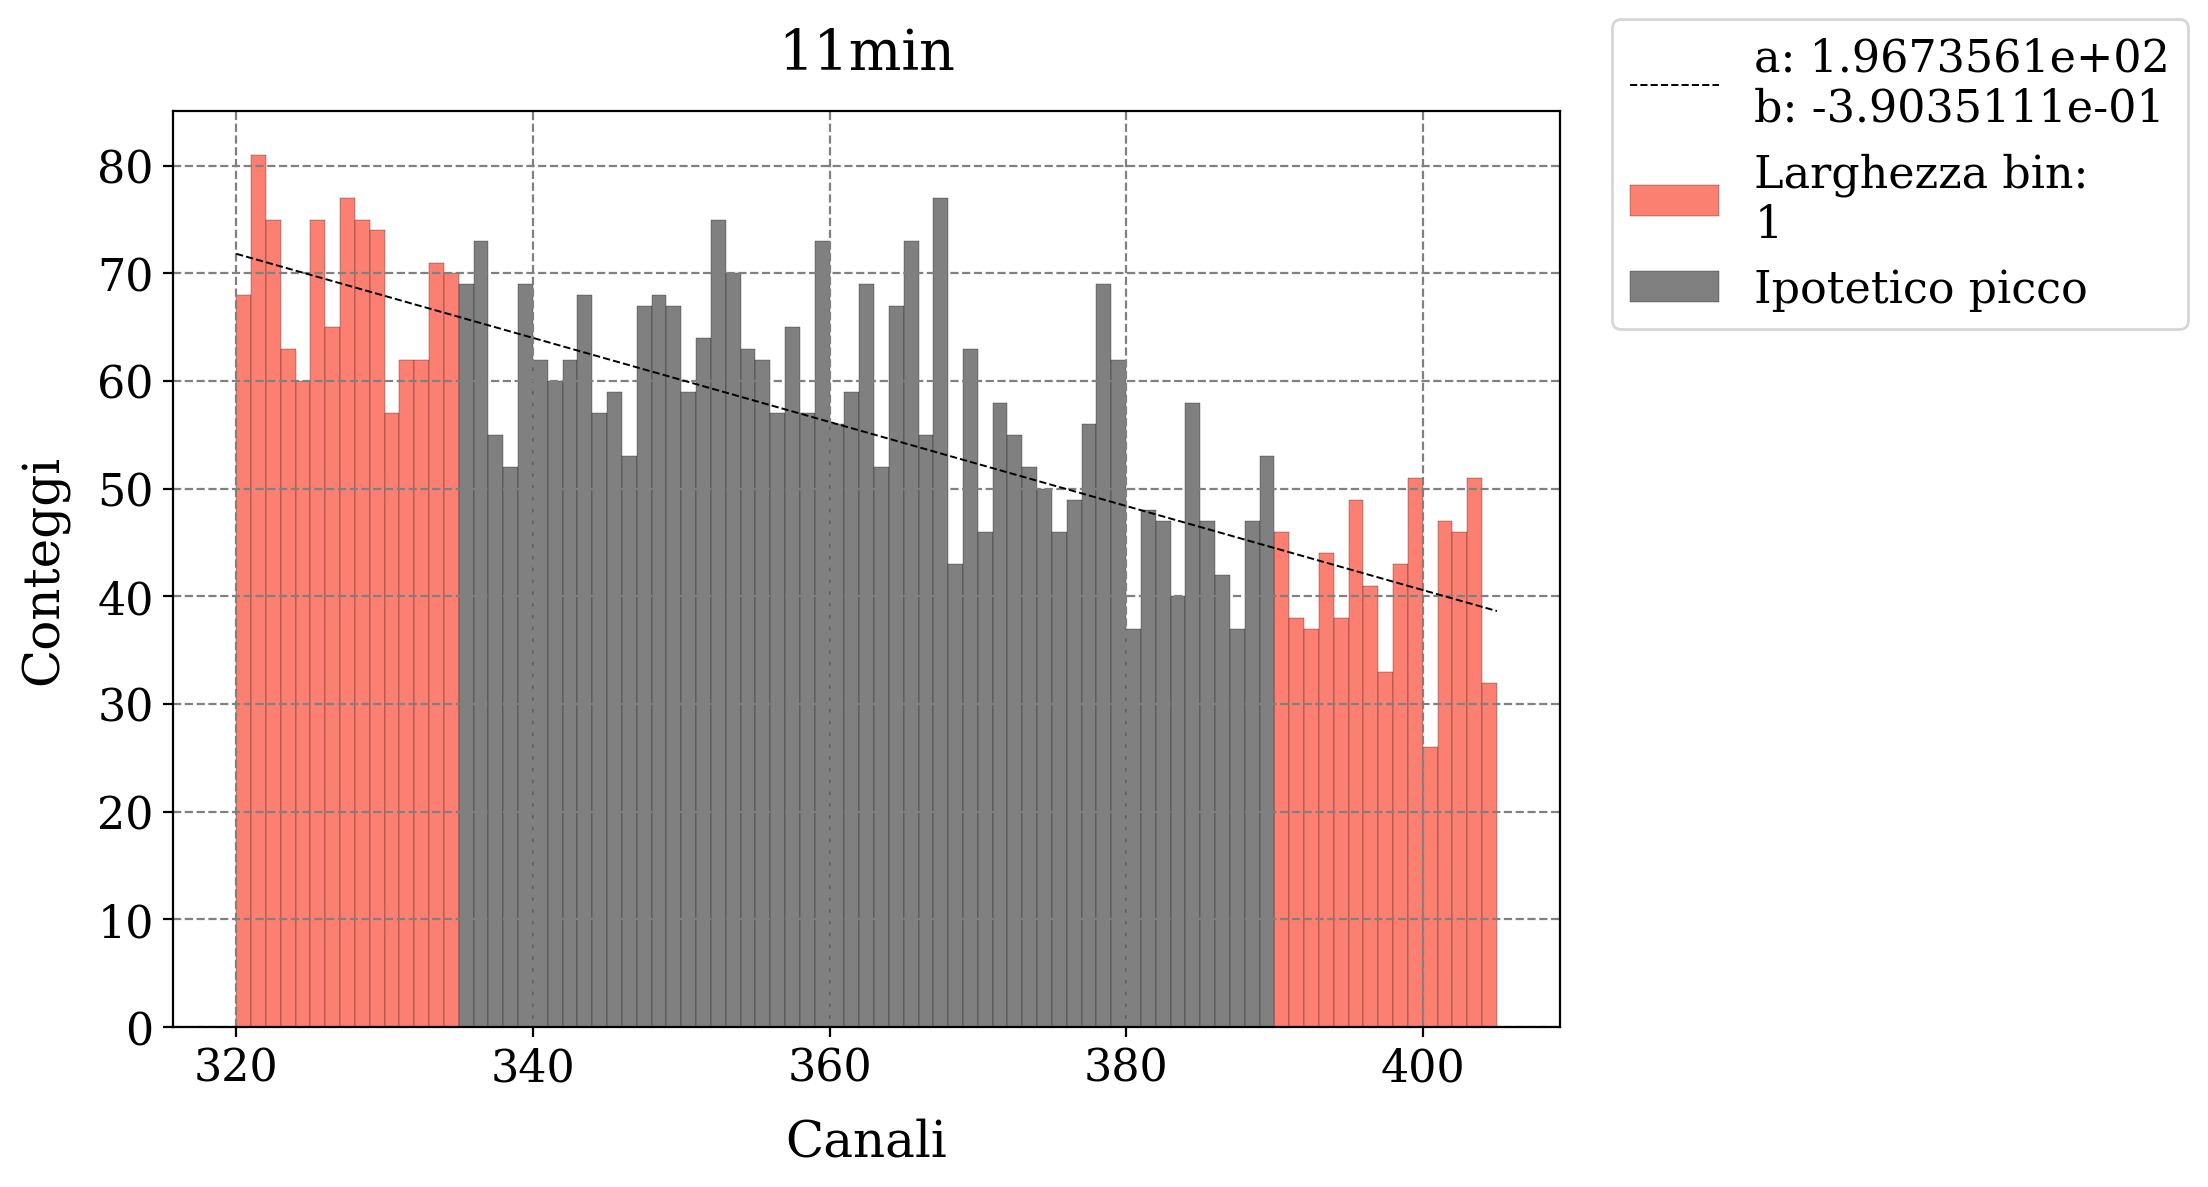

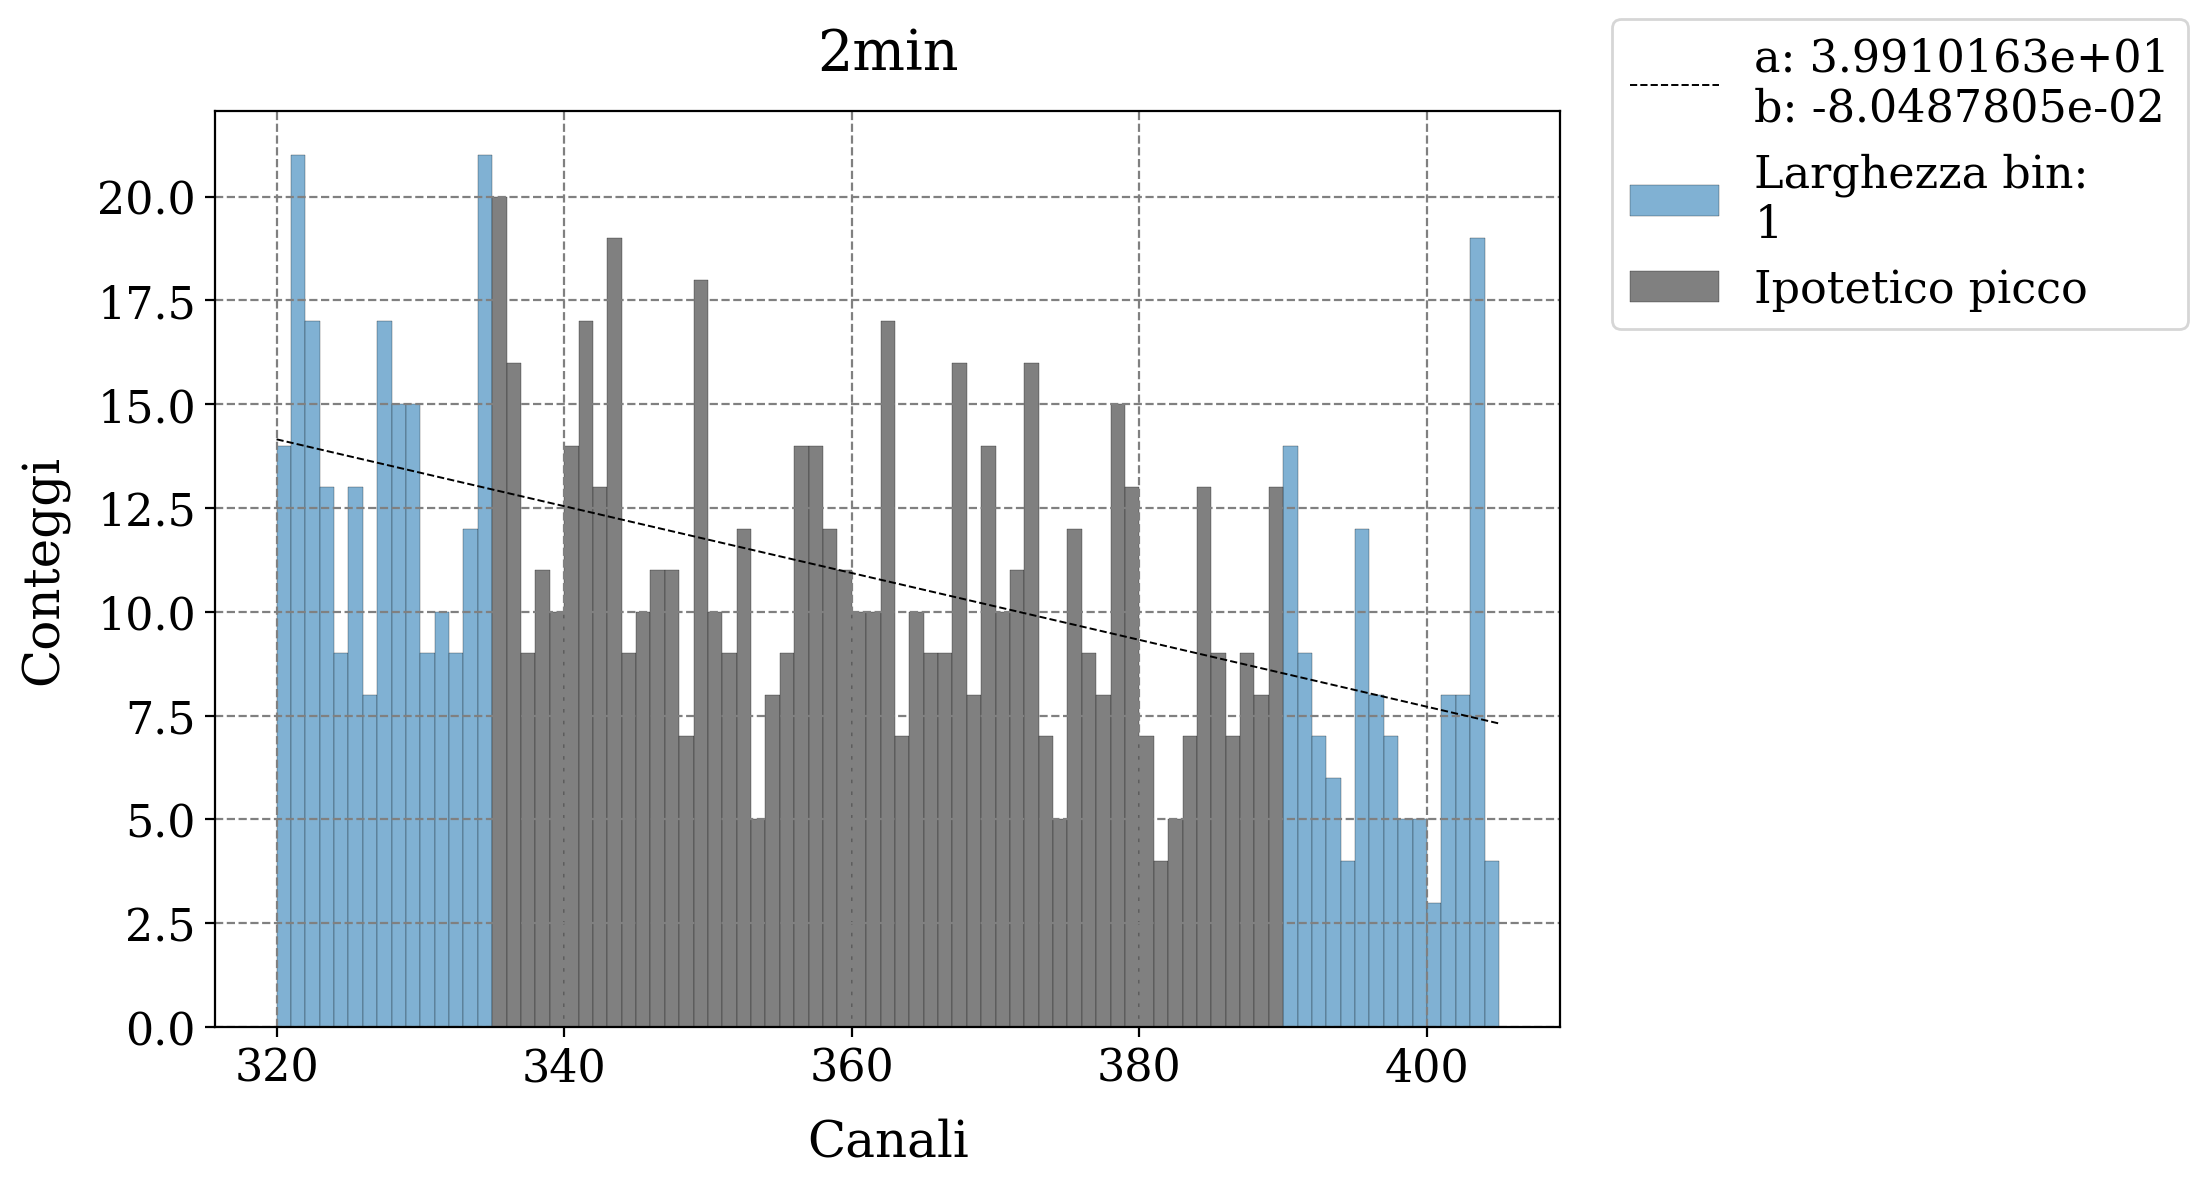

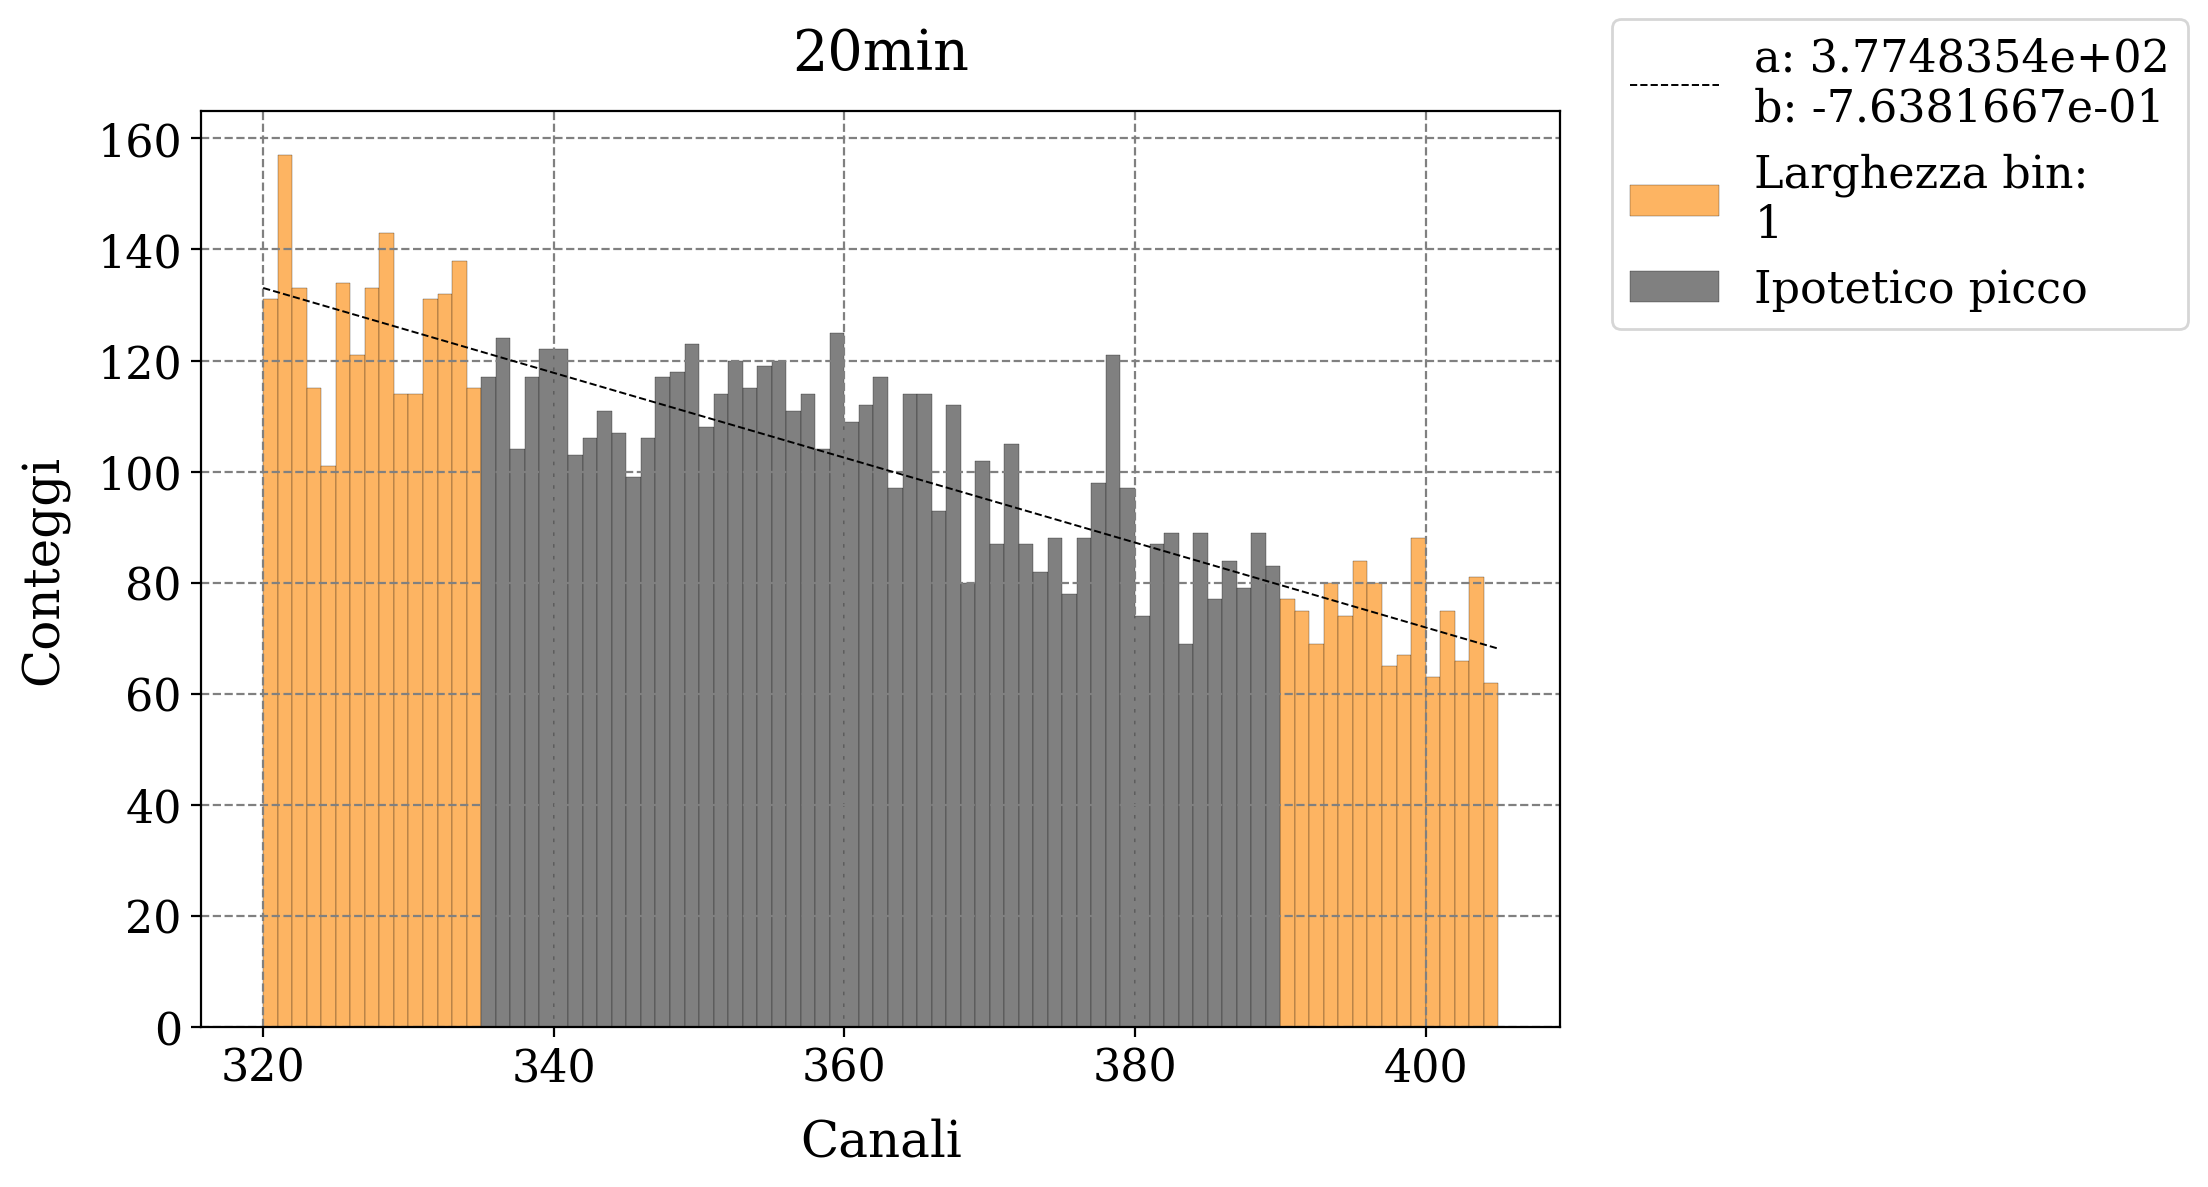

In [78]:
centri_storage, contenuti_storage, a_storage, b_storage, c_storage, titoli_storage, N_storage = [],[],[],[],[],[],[]
gf.imposta_stile_globale()
cmap = plt.get_cmap('Set3')
color_cycle = itertools.cycle(cmap.colors)

for file, titolo in zip(output_files, titoli):
    dati = np.loadtxt(file)
    centri = dati[:,0].tolist()
    frequenze = dati[:,1].tolist()

# Fitting
    xdata = np.array(centri[i1:i2] + centri[i3:i4])
    ydata = np.array(frequenze[i1:i2] + frequenze[i3:i4])
    popt, pcov = curve_fit(lin_func, xdata, ydata, absolute_sigma=True)
    a, b = popt
    sa, sb = np.sqrt(np.diag(pcov))

# Grafico Curva Fit
    x = np.linspace(index_inizio, index_fine, 100)
    y = lin_func(x,a,b)

# Plotting
    fig, ax = plt.subplots()
    color=next(color_cycle)
    ax.plot(x,y, color = 'black', linestyle = '--', linewidth=0.7, label =f"a: {a:.7e}\nb: {b:.7e}")
    ax.bar(xdata,ydata, width=centri[1]-centri[0], color=color, edgecolor='black', linewidth=0.1, label=f"Larghezza bin:\n{bin}")
    xdata = np.array(centri[i2:i3])
    ydata = np.array(frequenze[i2:i3])
    ax.bar(xdata,ydata, width=centri[1]-centri[0], color="gray", edgecolor='black', linewidth=0.1, label="Ipotetico picco")
    if bin == 1:
        xlabel = "Canali"
    else:
        xlabel = f"Canali (diviso {bin})"
    gf.parametri_grafico(ax, titolo=titolo, xlabel=xlabel, ylabel="Conteggi")

# Salvataggio
    gf.salva_grafico(fig, file.replace('txt','pdf').replace('Data','Images'))

# 3. Chi Quadro

E' eseguito il test del chi quadro, con NDOF uguale alla dimensione del campione a cui viene sottratto il numero di parametri (cioè tre, a,b e c). Le incertezze utilizzate sono date dalla radice quadrata del numero di conteggi per ogni bin.

In [24]:
for j in range(len(centri_storage)):
    elaborato_file = f"./Elaborati/elaborato_{titoli_storage[j]}.txt"
    with open(elaborato_file, 'w') as output_elab:
        NDOF = len(contenuti_storage[j]) - len(popt)
        output_elab.write("Test Chi Quadro_____________________________________________\n")
        output_elab.write(f"{'x':<10}{'y':<10}{'sy':<13}{'y*':<14}{'Chi-quadro':<13}\n")
        sum1 = 0.
        for i in range(len(centri_storage[j])):
            y = contenuti_storage[j][i]
            y_star = a_storage[j] * np.exp(b_storage[j]*centri_storage[j][i]) + c_storage[j]
            sy_test = np.sqrt(contenuti_storage[j][i])
            if contenuti_storage[j][i] * (1 - contenuti_storage[j][i]/N_storage[j]) == 0:
                print(f"Errore:\nserie: {titoli_storage[j]}\nnumero: {[i]}")
                output_elab.write(f"{centri_storage[j][i]:<10.1f}{contenuti_storage[j][i]:<10.1f}{sy:<13.3f}{y_star:<14.3f}{chi_quadro_i:<13.3f}\n")
                continue
            sy = np.sqrt(contenuti_storage[j][i] * (1 - contenuti_storage[j][i]/N_storage[j]))
            chi_quadro_i = ((y - y_star) / sy) ** 2
            sum1 += chi_quadro_i
            if centri_storage[j][i] == 350.5 or centri_storage[j][i] == 370.5:
                output_elab.write(f"{centri_storage[j][i]:<10.1f}{contenuti_storage[j][i]:<10.1f}{sy:<13.3f}{y_star:<14.3f}{chi_quadro_i:<13.3f}<--\n")
            else:
                output_elab.write(f"{centri_storage[j][i]:<10.1f}{contenuti_storage[j][i]:<10.1f}{sy:<13.3f}{y_star:<14.3f}{chi_quadro_i:<13.3f}\n")
        chi_quadro = sum1
        output_elab.write(f"\nGradi di liberta = {NDOF}\n")
        output_elab.write(f"Chi-quadro = {chi_quadro}\n")
        p_value = chi2.sf(chi_quadro, NDOF)
        output_elab.write(f"p-value = {p_value}\n\n")
        #print(f"{sy}\t\t{sy_test}")

Errore:
serie: 2min
numero: [183]


/tmp/ipykernel_44849/3886546118.py:16: RuntimeWarning: invalid value encountered in sqrt
  sy = np.sqrt(contenuti_storage[j][i] * (1 - contenuti_storage[j][i]/N_storage[j]))
